In [18]:
# Import essential libraries for data manipulation and visualization
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical operations
import matplotlib.pyplot as plt  # Data visualization
import seaborn as sns  # Statistical data visualization

In [19]:
# Load the training dataset from CSV file
data = pd.read_csv("train.csv")

In [20]:
# Display the first few rows of the dataset to understand its structure
data

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


In [21]:
# Display dataset information: column names, data types, and memory usage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [22]:
# Check for missing values in each column
data.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

<Axes: >

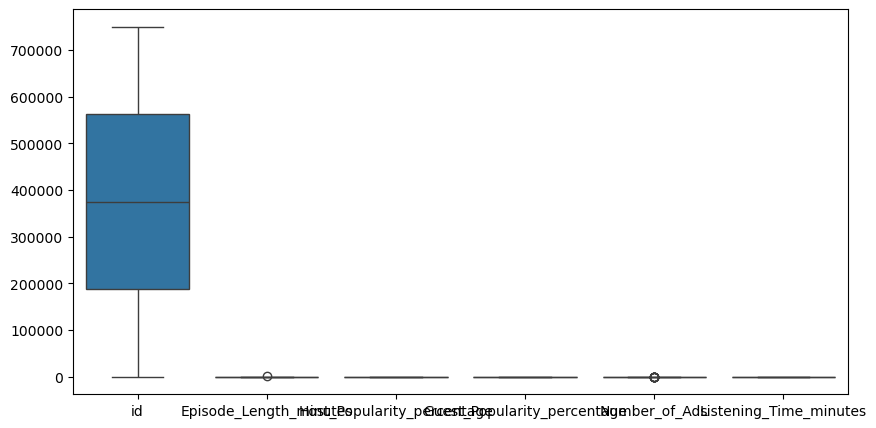

In [23]:
# Visualize data distribution and detect outliers using boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data)

In [24]:
# Handle missing values in Episode_Length_minutes by replacing with mean
data['Episode_Length_minutes'] = data['Episode_Length_minutes'].fillna(
    data['Episode_Length_minutes'].mean()
)

In [25]:
# Fill remaining missing values in Guest_Popularity_percentage with its mean
data.fillna(data['Guest_Popularity_percentage'].mean(), inplace=True)

In [26]:
# Verify that all missing values have been handled
data.isna().sum()

id                             0
Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
dtype: int64

In [27]:
# Remove outliers in Episode_Length_minutes using Interquartile Range (IQR) method
# Calculate Q1 (25th percentile), Q3 (75th percentile), and IQR
Q1 = data['Episode_Length_minutes'].quantile(0.25)
Q3 = data['Episode_Length_minutes'].quantile(0.75)
IQR = Q3 - Q1

# Calculate bounds for outlier detection
Lower_Bound = Q1 - 1.5 * IQR
Upper_Bound = Q3 + 1.5 * IQR

# Cap values outside the bounds to the respective boundary values
data['Episode_Length_minutes'] = np.where(
    data['Episode_Length_minutes'] < Lower_Bound, Lower_Bound,
    np.where(data['Episode_Length_minutes'] > Upper_Bound, Upper_Bound,
             data['Episode_Length_minutes'])
)

In [28]:
# Remove outliers in Number_of_Ads using Interquartile Range (IQR) method
# Calculate Q1 (25th percentile), Q3 (75th percentile), and IQR
Q1 = data['Number_of_Ads'].quantile(0.25)
Q3 = data['Number_of_Ads'].quantile(0.75)
IQR = Q3 - Q1

# Calculate bounds for outlier detection
Lower_Bound = Q1 - 1.5 * IQR
Upper_Bound = Q3 + 1.5 * IQR

# Cap values outside the bounds to the respective boundary values
data['Number_of_Ads'] = np.where(
    data['Number_of_Ads'] < Lower_Bound, Lower_Bound,
    np.where(data['Number_of_Ads'] > Upper_Bound, Upper_Bound,
             data['Number_of_Ads'])
)

<Axes: >

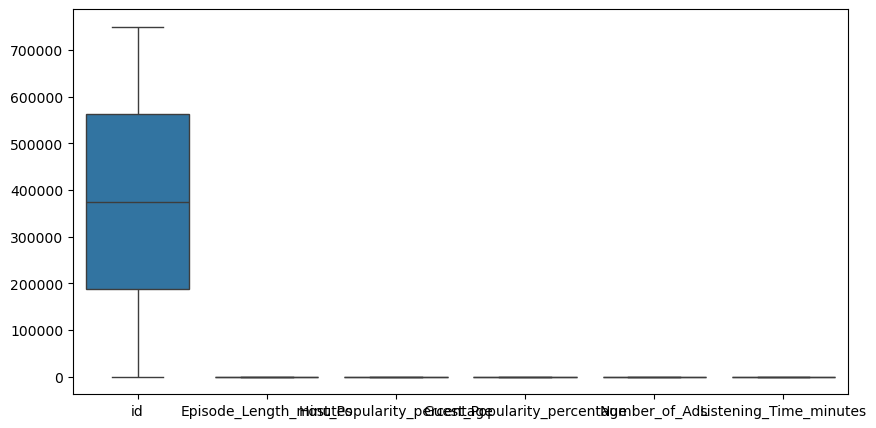

In [29]:
# Visualize data distribution after outlier removal to verify the cleaning
plt.figure(figsize=(10, 5))
sns.boxplot(data)

In [30]:
# Display the cleaned dataset
data

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,64.504738,True Crime,74.81,Thursday,Night,52.236449,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.800000,Comedy,66.95,Saturday,Afternoon,75.950000,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.900000,Education,69.97,Tuesday,Evening,8.970000,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.170000,Technology,57.22,Monday,Morning,78.700000,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.510000,Health,80.07,Monday,Afternoon,58.680000,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,Episode 25,75.660000,Education,69.36,Saturday,Morning,52.236449,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.750000,Business,35.21,Saturday,Night,52.236449,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.980000,Lifestyle,78.58,Thursday,Morning,84.890000,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.980000,Lifestyle,45.39,Thursday,Morning,93.270000,0.0,Negative,100.72939


In [31]:
# Remove irrelevant columns: 'id' (identifier) and 'Episode_Title' (non-numeric text)
data.drop(['id', 'Episode_Title'], axis=1, inplace=True)

In [32]:
# Display the dataset after dropping unnecessary columns
data

,Podcast_Name,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Mystery Matters,64.504738,True Crime,74.81,Thursday,Night,52.236449,0.0,Positive,31.41998
1,Joke Junction,119.800000,Comedy,66.95,Saturday,Afternoon,75.950000,2.0,Negative,88.01241
2,Study Sessions,73.900000,Education,69.97,Tuesday,Evening,8.970000,0.0,Negative,44.92531
3,Digital Digest,67.170000,Technology,57.22,Monday,Morning,78.700000,2.0,Positive,46.27824
4,Mind & Body,110.510000,Health,80.07,Monday,Afternoon,58.680000,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...
749995,Learning Lab,75.660000,Education,69.36,Saturday,Morning,52.236449,0.0,Negative,56.87058
749996,Business Briefs,75.750000,Business,35.21,Saturday,Night,52.236449,2.0,Neutral,45.46242
749997,Lifestyle Lounge,30.980000,Lifestyle,78.58,Thursday,Morning,84.890000,0.0,Negative,15.26000
749998,Style Guide,108.980000,Lifestyle,45.39,Thursday,Morning,93.270000,0.0,Negative,100.72939


In [33]:
# Apply one-hot encoding to convert categorical variables into binary features
# This expands 'Publication_Time' and 'Genre' into multiple binary columns
data = pd.get_dummies(data, columns=['Publication_Time', 'Genre'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Podcast_Name                 750000 non-null  object 
 1   Episode_Length_minutes       750000 non-null  float64
 2   Host_Popularity_percentage   750000 non-null  float64
 3   Publication_Day              750000 non-null  object 
 4   Guest_Popularity_percentage  750000 non-null  float64
 5   Number_of_Ads                750000 non-null  float64
 6   Episode_Sentiment            750000 non-null  object 
 7   Listening_Time_minutes       750000 non-null  float64
 8   Publication_Time_Afternoon   750000 non-null  bool   
 9   Publication_Time_Evening     750000 non-null  bool   
 10  Publication_Time_Morning     750000 non-null  bool   
 11  Publication_Time_Night       750000 non-null  bool   
 12  Genre_Business               750000 non-null  bool   
 13 

In [34]:
# Apply label encoding to convert remaining categorical variables into numeric format
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Encode 'Episode_Sentiment' column (e.g., Positive, Negative, Neutral -> 0, 1, 2)
data['Episode_Sentiment'] = le.fit_transform(data['Episode_Sentiment'])

# Encode 'Publication_Day' column (e.g., Monday, Tuesday, ... -> 0, 1, ...)
data['Publication_Day'] = le.fit_transform(data['Publication_Day'])

In [ ]:
# Convert boolean values in one-hot encoded columns to integer format (True -> 1, False -> 0)
# This ensures all features are numeric for neural network training

# Define a helper function to convert boolean values to integers
def convert(col):
    data[col] = data[col].map({True: 1, False: 0})

# List all one-hot encoded categorical columns that need conversion
columns = ['Publication_Time_Afternoon', 'Publication_Time_Evening', 'Publication_Time_Morning', 
           'Publication_Time_Night', 'Genre_Business', 'Genre_Comedy', 'Genre_Education', 
           'Genre_Health', 'Genre_Lifestyle', 'Genre_Music', 'Genre_News', 'Genre_Sports', 
           'Genre_Technology', 'Genre_True Crime']

# Apply the conversion function to all categorical columns
for col in columns:
    convert(col)